In [1]:
#####################################

import xrfclk
import xrfdc
from pynq import Overlay, allocate
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Configuration
# ============================================================

FS_IN = 2560e6
DECIMATION = 256
FS_OUT = FS_IN / DECIMATION       # 10 MSPS



FRAME_SAMPLES = 256               # output samples
INPUT_SAMPLES = FRAME_SAMPLES * DECIMATION



# ============================================================
# Configure clocks and load overlay
# ============================================================

xrfclk.set_ref_clks()

ol = Overlay("top_design.bit")

dma = ol.axi_dma_0


In [17]:


# ============================================================
# Allocate DMA buffers
# ============================================================

# MM2S:
# Stage 1 accepts 8 x int16 samples per 128-bit AXI beat.
#
# We still allocate an int16 array in DDR. The 128-bit DMA
# interface packs 8 consecutive int16 values into each beat.
tx_buffer = allocate(
    shape=(INPUT_SAMPLES,),
    dtype=np.int16
)

# S2MM:
# I-only output is 16 bits/sample
rx_buffer = allocate(
    shape=(FRAME_SAMPLES,),
    dtype=np.int16
)


# ============================================================
# Generate input sine wave
# ============================================================

n = np.arange(INPUT_SAMPLES)

FREQ = 2e6
AMPLITUDE = 1 * 32767

test_signal = AMPLITUDE * np.sin(
    2 * np.pi * FREQ * n / FS_IN
)

tx_buffer[:] = np.round(test_signal).astype(np.int16)

In [18]:
# ============================================================
# DMA loopback
#
# Arm receiver FIRST so that the decimation pipeline always
# has somewhere to send its output.
# ============================================================

dma.recvchannel.transfer(rx_buffer)
dma.sendchannel.transfer(tx_buffer)

dma.sendchannel.wait()
dma.recvchannel.wait()

Input samples  : 65536
Output samples : 256
Input Fs       : 2560.0 MSPS
Output Fs      : 10.0 MSPS
Expected tone  : 2.000 MHz
Measured tone  : 1.992 MHz
Peak level     : -6.24 dBFS
Max Mag        : 29338.00 


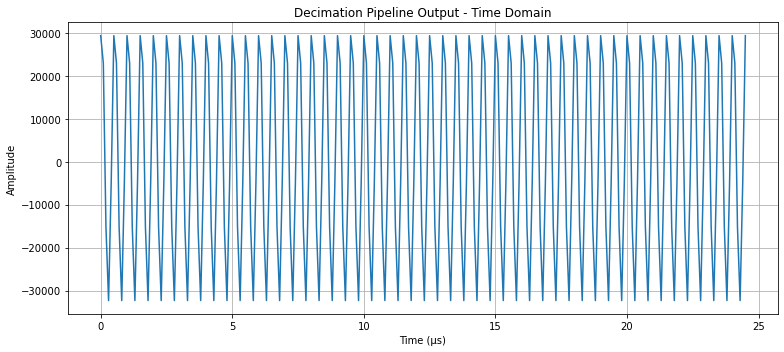

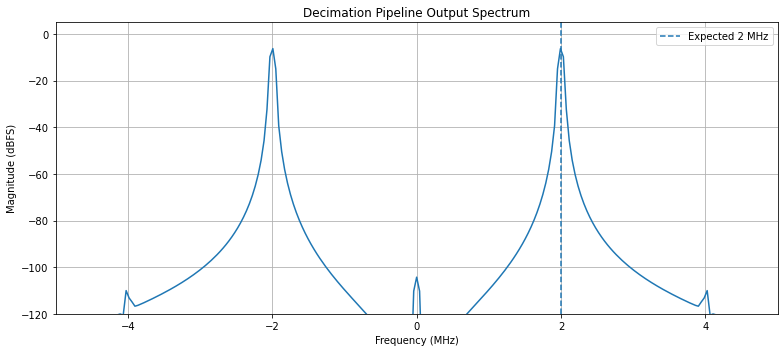

In [19]:
# Copy out of physically contiguous buffer
y = np.array(rx_buffer, dtype=np.int16)


# ============================================================
# Time-domain axes
# ============================================================

#t_in = np.arange(INPUT_SAMPLES) / FS_IN


# ============================================================
# FFT of output
# ============================================================
transient = 10
y = y[transient:] #remove transient
N = len(y)

t_out = np.arange(N) /FS_OUT

window = np.hanning(N)

Y = np.fft.fftshift(
    np.fft.fft(
        y.astype(np.float64) * window
    )
)

# Correct for window coherent gain
Y = Y / np.sum(window)

f = np.fft.fftshift(
    np.fft.fftfreq(
        N,
        d=1 / FS_OUT
    )
)

#max value
mag_max = np.max(y[transient:])

# dBFS
mag_dbfs = 20 * np.log10(np.maximum(
        np.abs(Y) / 32768.0,
        1e-12
    ))


# ============================================================
# Find spectral peak
# ============================================================

peak_idx = np.argmax(mag_dbfs)

peak_freq = f[peak_idx]
peak_level = mag_dbfs[peak_idx]


print(f"Input samples  : {INPUT_SAMPLES}")
print(f"Output samples : {FRAME_SAMPLES}")
print(f"Input Fs       : {FS_IN/1e6:.1f} MSPS")
print(f"Output Fs      : {FS_OUT/1e6:.1f} MSPS")
print(f"Expected tone  : {FREQ/1e6:.3f} MHz")
print(f"Measured tone  : {peak_freq/1e6:.3f} MHz")
print(f"Peak level     : {peak_level:.2f} dBFS")
print(f"Max Mag        : {mag_max:.2f} ")


# ============================================================
# Time-domain plot
# ============================================================

plt.figure(figsize=(11, 5))

plt.plot(
    t_out * 1e6,
    y
)

plt.xlabel("Time (µs)")
plt.ylabel("Amplitude")
plt.title("Decimation Pipeline Output - Time Domain")
plt.grid(True)

plt.tight_layout()
plt.show()


# ============================================================
# Frequency-domain plot
# ============================================================

plt.figure(figsize=(11, 5))

plt.plot(
    f / 1e6,
    mag_dbfs
)

plt.axvline(
    FREQ / 1e6,
    linestyle="--",
    label="Expected 2 MHz"
)

plt.xlabel("Frequency (MHz)")
plt.ylabel("Magnitude (dBFS)")
plt.title("Decimation Pipeline Output Spectrum")

plt.xlim(
    -FS_OUT / 2e6,
    FS_OUT / 2e6
)

plt.ylim(-120, 5)

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# Free buffers
# ============================================================

tx_buffer.freebuffer()
rx_buffer.freebuffer()

In [ ]:
np.sum(window)